# 06 - SQL Analytics and Exploratory Data Analysis

## Objective

This notebook uses DuckDB and the curated Airbnb star schema to answer business-oriented market questions for London and New York.

The analysis focuses on listing supply, availability patterns, neighbourhood-level pricing, room-type pricing, review activity, and price distributions.

## Analytical Engine

DuckDB is used as the local analytical engine because it supports SQL querying directly over curated CSV files without requiring a separate database server.

## Important Interpretation Notes

- London and New York source prices are recorded in different currencies.
- Raw price values should therefore be interpreted within each city and not treated as directly currency-normalized comparisons.
- `occupancy_rate` represents an occupancy/unavailability proxy based on calendar days marked unavailable.
- An unavailable calendar day may represent a guest booking, a host-blocked date, or another listing restriction.

## 1. Load the Curated Star Schema into DuckDB

The curated dimensional tables are loaded into DuckDB for SQL-based analytical querying.

The analytical model contains:

- `dim_city` for city-level context
- `dim_neighbourhood` for location-level context
- `dim_listing` for room type and property type context
- `fact_listing` for listing-level numerical measures

This structure allows business questions to be answered using joins between the fact table and relevant dimensions.

In [2]:
import duckdb
import pandas as pd

### Data Model Ready for Analysis

The star-schema tables have been loaded successfully into DuckDB.

The following SQL queries use the curated analytical layer rather than the raw source files. This improves consistency, reduces repeated transformation work, and ensures that all queries use the validated listing-level model.

In [3]:
con = duckdb.connect()

con.execute("""
CREATE OR REPLACE TABLE dim_city AS
SELECT * FROM read_csv_auto('../data/curated/dim_city.csv')
""")

con.execute("""
CREATE OR REPLACE TABLE dim_neighbourhood AS
SELECT * FROM read_csv_auto('../data/curated/dim_neighbourhood.csv')
""")

con.execute("""
CREATE OR REPLACE TABLE dim_listing AS
SELECT * FROM read_csv_auto('../data/curated/dim_listing.csv')
""")

con.execute("""
CREATE OR REPLACE TABLE fact_listing AS
SELECT * FROM read_csv_auto('../data/curated/fact_listing.csv')
""")

## 2. City-Level Market Overview

This query provides a high-level view of the Airbnb markets covered by the project.

The analysis includes:

- Total listing count
- Average cleaned price
- Average occupancy/unavailability proxy

Average prices are presented as descriptive values within their source market. Because the two cities use different source currencies, they should not be used to conclude that one city is definitively more expensive than the other without currency normalization.

In [4]:
con.sql("""
SELECT
    dc.city,
    ROUND(AVG(fl.price_clean), 2) AS avg_price,
    ROUND(AVG(fl.occupancy_rate), 3) AS avg_occupancy_rate,
    COUNT(*) AS listing_count
FROM fact_listing fl
JOIN dim_city dc
ON fl.city_id = dc.city_id
GROUP BY dc.city
ORDER BY avg_price DESC
""").df()

,city,avg_price,avg_occupancy_rate,listing_count
0,New York,255.00,0.570,35036
1,London,229.92,0.603,96871


### Business Interpretation

London has a larger observed listing supply than New York in the selected datasets.

London also has a slightly higher average occupancy/unavailability proxy than New York. This means that London listings were marked unavailable for a larger share of observed calendar days.

However, this should not be interpreted as confirmed booking occupancy because unavailable dates may include host-blocked dates or other availability restrictions.

## 3. Premium Neighbourhood Analysis

Median listing prices are calculated by neighbourhood within each city.

A minimum threshold of 50 listings is applied to reduce the influence of neighbourhoods with very small samples.

Neighbourhoods are ranked separately within London and New York because no currency normalization has been applied. The results therefore identify premium locations within each market rather than directly comparing raw prices across cities.

In [5]:
top_neighbourhoods = con.sql("""
WITH neighbourhood_metrics AS (
    SELECT
        dc.city,
        dn.neighbourhood_cleansed,
        ROUND(MEDIAN(fl.price_clean), 2) AS median_price,
        COUNT(*) AS listing_count
    FROM fact_listing fl
    JOIN dim_city dc
        ON fl.city_id = dc.city_id
    JOIN dim_neighbourhood dn
        ON fl.neighbourhood_id = dn.neighbourhood_id
    WHERE fl.price_clean IS NOT NULL
    GROUP BY
        dc.city,
        dn.neighbourhood_cleansed
    HAVING COUNT(*) >= 50
),
ranked_neighbourhoods AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY city
            ORDER BY median_price DESC
        ) AS price_rank
    FROM neighbourhood_metrics
)
SELECT
    city,
    price_rank,
    neighbourhood_cleansed,
    median_price,
    listing_count
FROM ranked_neighbourhoods
WHERE price_rank <= 5
ORDER BY city, price_rank
""").df()

top_neighbourhoods

,city,price_rank,neighbourhood_cleansed,median_price,listing_count
0,London,1,City of London,248.00,436
1,London,2,Kensington and Chelsea,225.00,4768
2,London,3,Westminster,220.00,8443
3,London,4,Camden,160.00,4330
4,London,5,Hammersmith and Fulham,144.00,2669
5,New York,1,Tribeca,525.83,69
6,New York,2,SoHo,431.10,151
7,New York,3,Financial District,397.61,293
8,New York,4,Greenwich Village,385.98,102
9,New York,5,Theater District,344.00,269


### Business Interpretation

Within London, City of London, Kensington and Chelsea, Westminster, Camden, and Hammersmith and Fulham have the highest median listing prices among neighbourhoods with at least 50 listings.

Within New York, Tribeca, SoHo, Financial District, Greenwich Village, and Theater District have the highest median listing prices among qualifying neighbourhoods.

These neighbourhoods represent premium submarkets within their respective cities. They may be useful areas for deeper market analysis, pricing strategy review, or property-type comparison.

The raw price values should not be compared directly between London and New York because the datasets use different source currencies.

## 4. Availability and Occupancy-Unavailability Proxy Analysis

This query compares the average availability rate and occupancy/unavailability proxy across the two cities.

Availability rate represents the proportion of observed calendar days that were marked available.

Occupancy rate represents the proportion of observed calendar days marked unavailable. It is treated as an occupancy/unavailability proxy rather than confirmed booking occupancy.

In [6]:
con.sql("""
SELECT
    dc.city,
    ROUND(AVG(fl.occupancy_rate), 3) AS avg_occupancy_rate,
    ROUND(AVG(fl.availability_rate), 3) AS avg_availability_rate
FROM fact_listing fl
JOIN dim_city dc
    ON fl.city_id = dc.city_id
GROUP BY dc.city
ORDER BY avg_occupancy_rate DESC
""").df()

,city,avg_occupancy_rate,avg_availability_rate
0,London,0.603,0.397
1,New York,0.570,0.430


## 4. Availability and Occupancy-Unavailability Proxy Analysis

This query compares the average availability rate and occupancy/unavailability proxy across the two cities.

Availability rate represents the proportion of observed calendar days that were marked available.

Occupancy rate represents the proportion of observed calendar days marked unavailable. It is treated as an occupancy/unavailability proxy rather than confirmed booking occupancy.

## 5. Room Type and Pricing Analysis

This query analyses average and median listing prices by room type within each city.

Median prices are included because Airbnb price distributions are heavily right-skewed. A small number of unusually expensive listings can increase the average price substantially.

The analysis is interpreted within each city because raw source prices are not currency-normalized across markets.

In [7]:
con.sql("""
SELECT
    dc.city,
    dl.room_type,
    ROUND(AVG(fl.price_clean), 2) AS avg_price,
    ROUND(MEDIAN(fl.price_clean), 2) AS median_price,
    COUNT(*) AS listing_count
FROM fact_listing fl
JOIN dim_city dc
    ON fl.city_id = dc.city_id
JOIN dim_listing dl
    ON fl.listing_id = dl.listing_id
WHERE fl.price_clean IS NOT NULL
GROUP BY dc.city, dl.room_type
ORDER BY dc.city, median_price DESC
""").df()

,city,room_type,avg_price,median_price,listing_count
0,London,Hotel room,657.83,281.00,72
1,London,Entire home/apt,279.35,175.00,42318
2,London,Private room,121.71,61.00,19382
3,London,Shared room,96.91,32.00,191
4,New York,Hotel room,814.35,529.00,332
5,New York,Entire home/apt,297.97,205.41,11003
6,New York,Private room,184.76,100.86,9164
7,New York,Shared room,178.02,66.41,194


### Business Interpretation

Within both cities, hotel rooms and entire homes or apartments generally have higher median prices than private rooms and shared rooms.

Entire homes or apartments represent the largest priced room-type category in both markets, while private rooms offer a lower-priced accommodation option.

Hotel-room results should be interpreted with care because the number of hotel-room listings is substantially smaller than the number of entire homes or private rooms.

## 6. Review Activity Analysis

This query identifies listings with the highest total review counts.

Review volume provides an indication of historical guest engagement and listing visibility. However, it should not be treated as a direct measure of revenue, profitability, or current demand.

The query combines review activity with room type, property type, price, and calendar availability context.

In [8]:
con.sql("""
SELECT
    dc.city,
    fl.listing_id,
    dl.room_type,
    dl.property_type,
    fl.total_reviews,
    ROUND(fl.price_clean, 2) AS price_clean,
    ROUND(fl.occupancy_rate, 3) AS occupancy_rate
FROM fact_listing fl
JOIN dim_city dc
    ON fl.city_id = dc.city_id
JOIN dim_listing dl
    ON fl.listing_id = dl.listing_id
WHERE fl.total_reviews IS NOT NULL
ORDER BY fl.total_reviews DESC
LIMIT 10
""").df()

,city,listing_id,room_type,property_type,total_reviews,price_clean,occupancy_rate
0,New York,858697692672545141,Private room,Private room in bed and breakfast,4310.0,99.00,0.005
1,New York,51619634,Private room,Room in hotel,2300.0,305.50,0.008
2,New York,691676460109271194,Entire home/apt,Entire loft,2276.0,140.00,0.044
3,New York,37122502,Private room,Room in boutique hotel,1998.0,250.00,0.156
4,London,47408549,Private room,Room in hotel,1902.0,162.00,0.008
5,London,43120947,Private room,Room in hotel,1647.0,114.00,0.036
6,New York,992970965790772607,Private room,Room in hotel,1484.0,185.56,0.148
7,London,19670926,Entire home/apt,Entire serviced apartment,1443.0,240.00,0.249
8,New York,700888293266225258,Entire home/apt,Entire loft,1337.0,140.00,0.047
9,New York,53132475,Private room,Room in hotel,1231.0,277.00,0.014


### Business Interpretation

The most-reviewed listings include a mix of private rooms, hotel-style rooms, lofts, serviced apartments, and other accommodation types.

High review counts may indicate long-term platform presence, strong guest demand, frequent bookings, or sustained listing activity.

However, high review volume does not automatically indicate the most profitable listing because the available dataset does not include confirmed bookings, operating costs, cleaning costs, or realized revenue.

## 7. Price Distribution Analysis

Price distributions are visualized separately for London and New York.

Extreme price values can flatten visualizations and obscure the main market pattern. Therefore, histogram and boxplot analysis should use values up to each city's 99th percentile while preserving the original values in the curated dataset.

The purpose of this analysis is to understand within-city price variation, identify skewness, and compare room-type pricing structures.

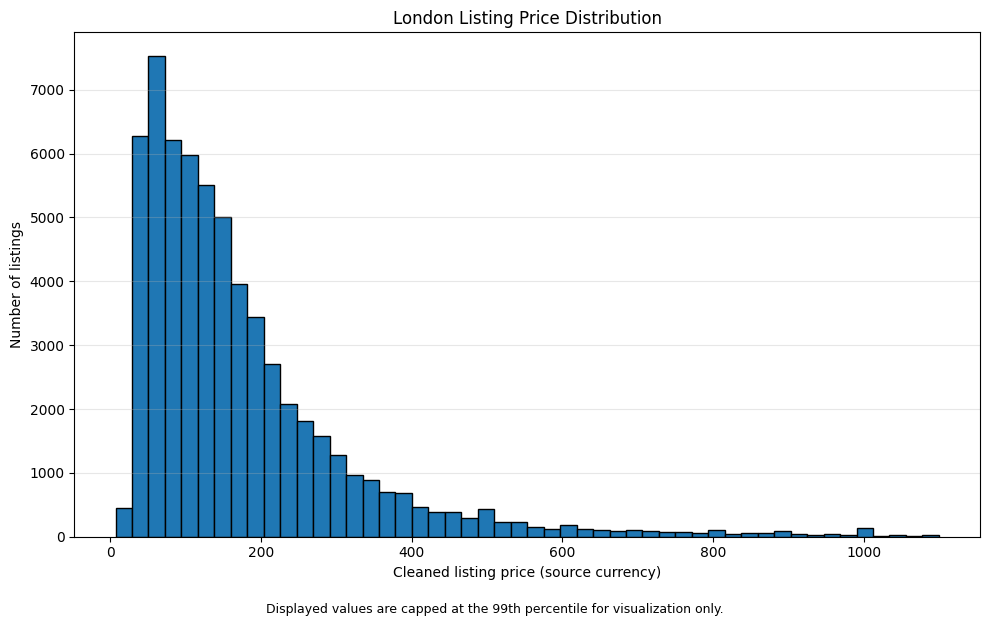

In [9]:
import matplotlib.pyplot as plt
from pathlib import Path

# Create a folder for report-ready figures
figure_dir = Path("../docs/figures")
figure_dir.mkdir(parents=True, exist_ok=True)

# Load city-level price data from the star schema
price_by_city = con.sql("""
SELECT
    dc.city,
    fl.price_clean
FROM fact_listing fl
JOIN dim_city dc
    ON fl.city_id = dc.city_id
WHERE fl.price_clean IS NOT NULL
""").df()

# Separate London prices and limit chart display to the 99th percentile
london_prices = price_by_city.loc[
    price_by_city["city"] == "London",
    "price_clean"
]

london_price_cap = london_prices.quantile(0.99)

london_prices_for_chart = london_prices[
    london_prices <= london_price_cap
]

plt.figure(figsize=(10, 6))

plt.hist(
    london_prices_for_chart,
    bins=50,
    edgecolor="black"
)

plt.title("London Listing Price Distribution")
plt.xlabel("Cleaned listing price (source currency)")
plt.ylabel("Number of listings")
plt.grid(axis="y", alpha=0.3)

plt.figtext(
    0.5,
    -0.03,
    "Displayed values are capped at the 99th percentile for visualization only.",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.savefig(
    figure_dir / "london_price_histogram.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### London Price Distribution Interpretation

London listing prices are strongly right-skewed. Most listings are concentrated in the lower and middle price range, while a smaller number of high-priced listings create a long upper tail.

This indicates that median price is more representative than average price when describing the typical London listing. The small number of premium listings can increase average-price measures substantially.

Values above the 99th percentile are excluded from the visual display only. They remain preserved in the underlying curated dataset.

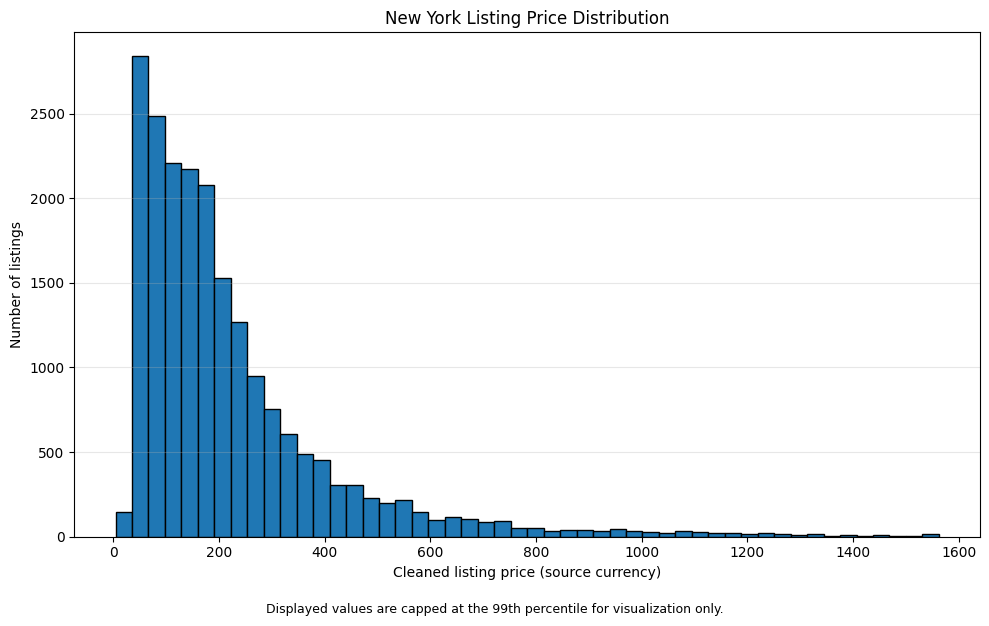

In [10]:
# Separate New York prices and limit chart display to the 99th percentile
ny_prices = price_by_city.loc[
    price_by_city["city"] == "New York",
    "price_clean"
]

ny_price_cap = ny_prices.quantile(0.99)

ny_prices_for_chart = ny_prices[
    ny_prices <= ny_price_cap
]

plt.figure(figsize=(10, 6))

plt.hist(
    ny_prices_for_chart,
    bins=50,
    edgecolor="black"
)

plt.title("New York Listing Price Distribution")
plt.xlabel("Cleaned listing price (source currency)")
plt.ylabel("Number of listings")
plt.grid(axis="y", alpha=0.3)

plt.figtext(
    0.5,
    -0.03,
    "Displayed values are capped at the 99th percentile for visualization only.",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.savefig(
    figure_dir / "new_york_price_histogram.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### New York Price Distribution Interpretation

New York listing prices also show a strongly right-skewed distribution. Most listings are concentrated in lower and mid-range price bands, while a smaller group of premium listings extends the upper tail.

This distribution supports the use of median prices and percentile-based thresholds in later analysis because extreme values can distort average-price comparisons.

Values above the 99th percentile are excluded from the visual display only. They remain preserved in the underlying curated dataset.

### Price Boxplot by Room Type

The boxplot below compares the distribution of cleaned listing prices across room types within each city.

Boxplots are useful because they show the median, interquartile range, and remaining high-price variation more clearly than averages alone.

The visual should be interpreted within each city and not as a currency-normalized comparison between London and New York.

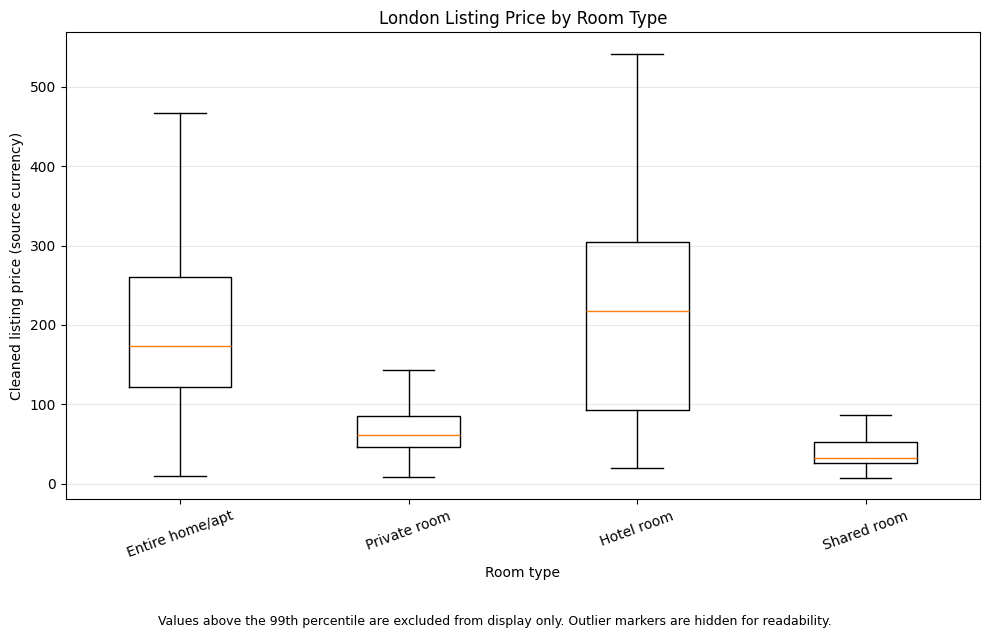

In [11]:
# Load room type and price data from the star schema
room_type_prices = con.sql("""
SELECT
    dc.city,
    dl.room_type,
    fl.price_clean
FROM fact_listing fl
JOIN dim_city dc
    ON fl.city_id = dc.city_id
JOIN dim_listing dl
    ON fl.listing_id = dl.listing_id
WHERE fl.price_clean IS NOT NULL
""").df()

# Keep a consistent room-type order where values are available
room_type_order = [
    "Entire home/apt",
    "Private room",
    "Hotel room",
    "Shared room"
]

# London room-type boxplot, capped at London's 99th percentile for readability
london_room_prices = room_type_prices[
    room_type_prices["city"] == "London"
].copy()

london_room_cap = london_room_prices["price_clean"].quantile(0.99)

london_room_prices = london_room_prices[
    london_room_prices["price_clean"] <= london_room_cap
]

london_boxplot_data = []
london_labels = []

for room_type in room_type_order:
    values = london_room_prices.loc[
        london_room_prices["room_type"] == room_type,
        "price_clean"
    ].dropna()

    if not values.empty:
        london_boxplot_data.append(values)
        london_labels.append(room_type)

plt.figure(figsize=(10, 6))

plt.boxplot(
    london_boxplot_data,
    tick_labels=london_labels,
    showfliers=False
)

plt.title("London Listing Price by Room Type")
plt.xlabel("Room type")
plt.ylabel("Cleaned listing price (source currency)")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.figtext(
    0.5,
    -0.05,
    "Values above the 99th percentile are excluded from display only. Outlier markers are hidden for readability.",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.savefig(
    figure_dir / "london_room_type_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### London Room-Type Price Interpretation

Within London, hotel rooms and entire homes or apartments have higher typical listing prices than private rooms and shared rooms.

Private rooms provide a lower-priced accommodation option, while shared rooms have the lowest typical prices. Hotel rooms show the widest visible price variation, although their sample size is smaller than the main room-type categories.

This suggests that room type is an important pricing dimension for London market analysis.

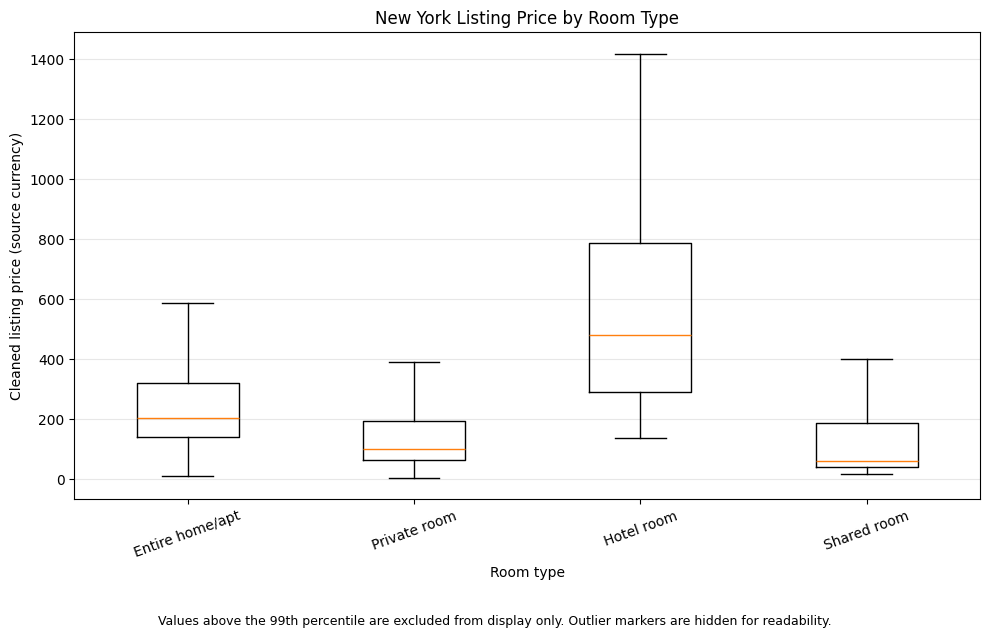

In [12]:
# New York room-type boxplot, capped at New York's 99th percentile for readability
ny_room_prices = room_type_prices[
    room_type_prices["city"] == "New York"
].copy()

ny_room_cap = ny_room_prices["price_clean"].quantile(0.99)

ny_room_prices = ny_room_prices[
    ny_room_prices["price_clean"] <= ny_room_cap
]

ny_boxplot_data = []
ny_labels = []

for room_type in room_type_order:
    values = ny_room_prices.loc[
        ny_room_prices["room_type"] == room_type,
        "price_clean"
    ].dropna()

    if not values.empty:
        ny_boxplot_data.append(values)
        ny_labels.append(room_type)

plt.figure(figsize=(10, 6))

plt.boxplot(
    ny_boxplot_data,
    tick_labels=ny_labels,
    showfliers=False
)

plt.title("New York Listing Price by Room Type")
plt.xlabel("Room type")
plt.ylabel("Cleaned listing price (source currency)")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.figtext(
    0.5,
    -0.05,
    "Values above the 99th percentile are excluded from display only. Outlier markers are hidden for readability.",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.savefig(
    figure_dir / "new_york_room_type_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### New York Room-Type Price Interpretation

Within New York, hotel rooms have the highest typical prices and the widest price variation among the displayed room types.

Entire homes or apartments also have higher typical prices than private rooms and shared rooms. Private rooms provide a mid-to-lower price alternative, while shared rooms have the lowest typical prices.

This indicates that room type is a major driver of pricing structure within the New York market.

## 7. Statistical Thinking: Room-Type Price Comparison

### Objective

Test whether **Entire home/apt** listings have a higher source-price distribution than **Private room** listings within London and New York.

The cities are tested separately because source prices are recorded in different currencies.

### Method

A one-sided **Mann–Whitney U test** was used because Airbnb prices are right-skewed and include high-value observations.

- **H₀:** Entire home/apt listings do not have a higher price distribution than Private room listings.
- **H₁:** Entire home/apt listings have a higher price distribution than Private room listings.

Only valid positive prices were used. A city-specific 99th-percentile cap was applied to reduce the influence of extreme values. Bonferroni adjustment was applied because two tests were conducted.

In [13]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# Load the processed master dataset
stats_df = pd.read_csv(
    "../data/processed/pipeline_master_dataset.csv",
    low_memory=False
)

# Keep only the two room types required for the hypothesis test
stats_df = stats_df[
    stats_df["room_type"].isin(
        ["Entire home/apt", "Private room"]
    )
].copy()

stats_df["price_clean"] = pd.to_numeric(
    stats_df["price_clean"],
    errors="coerce"
)

stats_df = stats_df.dropna(subset=["price_clean"])
stats_df = stats_df[stats_df["price_clean"] > 0].copy()

results = []

for city in sorted(stats_df["city"].dropna().unique()):

    city_df = stats_df[stats_df["city"] == city].copy()

    # Cap only the displayed/test subset at the 99th percentile
    # to reduce the influence of extreme source-price values.
    price_cap = city_df["price_clean"].quantile(0.99)

    city_df = city_df[
        city_df["price_clean"] <= price_cap
    ].copy()

    entire_home_prices = city_df.loc[
        city_df["room_type"] == "Entire home/apt",
        "price_clean"
    ]

    private_room_prices = city_df.loc[
        city_df["room_type"] == "Private room",
        "price_clean"
    ]

    # H0: Entire homes do not have a higher source-price distribution.
    # H1: Entire homes have a higher source-price distribution.
    u_statistic, p_value = mannwhitneyu(
        entire_home_prices,
        private_room_prices,
        alternative="greater",
        method="asymptotic",
    )

    # Rank-biserial correlation: effect size for Mann-Whitney U.
    rank_biserial = (
        (2 * u_statistic)
        / (len(entire_home_prices) * len(private_room_prices))
    ) - 1

    effect_size = abs(rank_biserial)

    if effect_size >= 0.50:
        effect_label = "Large"
    elif effect_size >= 0.30:
        effect_label = "Medium"
    elif effect_size >= 0.10:
        effect_label = "Small"
    else:
        effect_label = "Negligible"

    results.append(
        {
            "city": city,
            "entire_home_n": len(entire_home_prices),
            "private_room_n": len(private_room_prices),
            "entire_home_median_price": entire_home_prices.median(),
            "private_room_median_price": private_room_prices.median(),
            "median_difference": (
                entire_home_prices.median()
                - private_room_prices.median()
            ),
            "mann_whitney_u": u_statistic,
            "p_value": p_value,
            "bonferroni_adjusted_p_value": min(p_value * 2, 1.0),
            "rank_biserial_correlation": rank_biserial,
            "effect_size_interpretation": effect_label,
        }
    )

statistical_test_results = pd.DataFrame(results)

statistical_test_results[
    [
        "entire_home_median_price",
        "private_room_median_price",
        "median_difference",
        "mann_whitney_u",
        "p_value",
        "bonferroni_adjusted_p_value",
        "rank_biserial_correlation",
    ]
] = statistical_test_results[
    [
        "entire_home_median_price",
        "private_room_median_price",
        "median_difference",
        "mann_whitney_u",
        "p_value",
        "bonferroni_adjusted_p_value",
        "rank_biserial_correlation",
    ]
].round(4)

display(statistical_test_results)

statistical_test_results.to_csv(
    "../data/curated/statistical_test_room_type_price.csv",
    index=False,
)

,city,entire_home_n,private_room_n,entire_home_median_price,private_room_median_price,median_difference,mann_whitney_u,p_value,bonferroni_adjusted_p_value,rank_biserial_correlation,effect_size_interpretation
0,London,41770,19315,173.0,61.000,112.000,733069377.5,0.0,0.0,0.8173,Large
1,New York,10857,9108,203.5,100.205,103.295,73489015.0,0.0,0.0,0.4863,Medium


### Results

- **London:** Entire home/apt median = 173.00; Private room median = 61.00; adjusted **p < 0.001**; large effect size (**r = 0.8173**).
- **New York:** Entire home/apt median = 203.50; Private room median = 100.21; adjusted **p < 0.001**; medium effect size (**r = 0.4863**).

### Business Interpretation

Entire home/apt listings have a statistically significant higher source-price distribution than Private room listings in both cities.

Room type is therefore an important within-city pricing factor. These results do not compare London and New York prices directly because source currencies were not normalized.

## SQL Analytics Summary and Next Steps

The SQL analysis demonstrates how the dimensional model can support market-intelligence questions using DuckDB.

Key outcomes:

1. London has a larger observed listing supply than New York in the selected datasets.
2. London has a slightly higher occupancy/unavailability proxy than New York.
3. Premium neighbourhoods were identified separately within each city using median price and a minimum listing-count threshold.
4. Room type is strongly associated with listing price within both markets.
5. High-review listings represent historically active listings but do not directly prove profitability or confirmed booking demand.
6. Price-distribution visualizations are used to support within-city analysis while avoiding misleading cross-currency comparisons.

The next notebook documents the reusable pipeline design that produces the cleaned, enriched, and curated datasets used throughout this analysis.